In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Đọc các file csv (đảm bảo file nằm cùng thư mục code)
orders = pd.read_csv('olist_orders_dataset_clean.csv')
items = pd.read_csv('olist_order_items_dataset_clean.csv')
payments = pd.read_csv('olist_order_payments_dataset_clean.csv')
products = pd.read_csv('olist_products_dataset_clean.csv')
reviews = pd.read_csv('olist_order_reviews_dataset_clean.csv')

In [4]:
# 2. Chuyển đổi thời gian 
date_cols = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for col in date_cols:
    # errors='coerce' sẽ biến các giá trị lỗi như "0" thành NaT
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# 3. Lọc đơn hàng đã giao (để đảm bảo có đủ ngày nhận hàng)
df_master = orders[orders['order_status'] == 'delivered'].copy()

In [5]:
# Độ trễ giao hàng (ngày): Dương là trễ, âm là sớm
df_master['raw_delivery_delay'] = (df_master['order_delivered_customer_date'] - df_master['order_estimated_delivery_date']).dt.total_seconds() / 86400

# Tổng thời gian chờ (ngày)
df_master['raw_lead_time'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.total_seconds() / 86400

# Tốc độ chuẩn bị hàng của Seller (ngày)
df_master['raw_seller_speed'] = (df_master['order_delivered_carrier_date'] - df_master['order_approved_at']).dt.total_seconds() / 86400

In [6]:
# Tính Freight Ratio (Tỷ lệ phí ship)
item_agg = items.groupby('order_id').agg({'price': 'sum', 'freight_value': 'sum'}).reset_index()
item_agg['raw_freight_ratio'] = item_agg['freight_value'] / (item_agg['price'] + 0.001)

# Lấy số kỳ trả góp lớn nhất của đơn hàng
pay_agg = payments.groupby('order_id').agg({'payment_installments': 'max'}).reset_index()
pay_agg.rename(columns={'payment_installments': 'raw_installments'}, inplace=True)

# Lấy thông tin mô tả và ảnh sản phẩm (tính trung bình nếu đơn có nhiều món)
order_items_prod = items.merge(products, on='product_id')
prod_agg = order_items_prod.groupby('order_id').agg({
    'product_description_lenght': 'mean',
    'product_photos_qty': 'mean'
}).reset_index()
prod_agg.rename(columns={'product_description_lenght': 'raw_desc_length', 'product_photos_qty': 'raw_photos_qty'}, inplace=True)

In [7]:
# Merge tất cả vào df_master
df_final = df_master[['order_id', 'raw_delivery_delay', 'raw_lead_time', 'raw_seller_speed']]
df_final = df_final.merge(item_agg[['order_id', 'raw_freight_ratio']], on='order_id', how='left')
df_final = df_final.merge(pay_agg, on='order_id', how='left')
df_final = df_final.merge(prod_agg, on='order_id', how='left')

# Xử lý Outliers (Clipping) để thang đo 0-1 không bị méo
df_final['raw_delivery_delay'] = df_final['raw_delivery_delay'].clip(-30, 30) # Trễ/Sớm quá 30 ngày coi như mức trần
df_final['raw_freight_ratio'] = df_final['raw_freight_ratio'].clip(0, 2)     # Ship đắt gấp 2 lần hàng là tối đa
df_final.fillna(0, inplace=True) # Lấp đầy các giá trị thiếu bằng 0

In [8]:
# 7. Chuẩn hóa MinMaxScaler (0-1)
scaler = MinMaxScaler()
raw_cols = [c for c in df_final.columns if c.startswith('raw_')]
norm_cols = [c.replace('raw_', 'norm_') for c in raw_cols]

df_final[norm_cols] = scaler.fit_transform(df_final[raw_cols])

In [9]:
df_final[norm_cols]

,norm_delivery_delay,norm_lead_time,norm_seller_speed,norm_freight_ratio,norm_installments,norm_desc_length,norm_photos_qty
0,0.381542,0.040245,0.584499,0.145377,0.041667,0.067134,0.20
1,0.410738,0.065745,0.578089,0.095871,0.041667,0.044589,0.05
2,0.212575,0.044814,0.577220,0.060100,0.125000,0.058116,0.05
3,0.283666,0.063010,0.589144,0.302216,0.041667,0.117234,0.15
4,0.346030,0.013709,0.579538,0.219084,0.041667,0.079158,0.20
...,...,...,...,...,...,...,...
96473,0.327176,0.039203,0.580094,0.090832,0.125000,0.380010,0.05
96474,0.478911,0.105872,0.581329,0.057461,0.125000,0.207415,0.20
96475,0.407920,0.118588,0.580712,0.157822,0.208333,0.125251,0.10
96476,0.166353,0.081508,0.589155,0.112756,0.166667,0.474198,0.05


In [10]:
# Kiểm tra giá trị nhỏ nhất và lớn nhất của cột chuẩn hóa
print("Giá trị Min:", df_final['norm_photos_qty'].min())
print("Giá trị Max:", df_final['norm_photos_qty'].max())

Giá trị Min: 0.0
Giá trị Max: 1.0


In [11]:
review_scores = reviews.groupby('order_id').agg({'review_score': 'mean'}).reset_index()
df_final_labeled = df_final.merge(review_scores, on='order_id', how='inner')

In [12]:
df_final_labeled

,order_id,raw_delivery_delay,raw_lead_time,raw_seller_speed,raw_freight_ratio,raw_installments,raw_desc_length,raw_photos_qty,norm_delivery_delay,norm_lead_time,norm_seller_speed,norm_freight_ratio,norm_installments,norm_desc_length,norm_photos_qty,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-7.107488,8.436574,2.366493,0.290754,1.0,268.0,4.0,0.381542,0.040245,0.584499,0.145377,0.041667,0.067134,0.20,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,-5.355729,13.782037,0.462882,0.191742,1.0,178.0,1.0,0.410738,0.065745,0.578089,0.095871,0.041667,0.044589,0.05,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,-17.245498,9.394213,0.204595,0.120199,3.0,232.0,1.0,0.212575,0.044814,0.577220,0.060100,0.125000,0.058116,0.05,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,-12.980069,13.208750,3.745833,0.604431,1.0,468.0,3.0,0.283666,0.063010,0.589144,0.302216,0.041667,0.117234,0.15,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,-9.238171,2.873877,0.893113,0.438169,1.0,316.0,4.0,0.346030,0.013709,0.579538,0.219084,0.041667,0.079158,0.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95827,9c5dedf39a927c1b2549525ed64a053c,-10.369433,8.218009,1.058310,0.181664,3.0,1517.0,1.0,0.327176,0.039203,0.580094,0.090832,0.125000,0.380010,0.05,5.0
95828,63943bddc261676b46f01ca7ac2f7bd8,-1.265324,22.193727,1.425058,0.114922,3.0,828.0,4.0,0.478911,0.105872,0.581329,0.057461,0.125000,0.207415,0.20,4.0
95829,83c1379a015df1e13d02aae0204711ab,-5.524803,24.859421,1.241782,0.315645,5.0,500.0,2.0,0.407920,0.118588,0.580712,0.157822,0.208333,0.125251,0.10,5.0
95830,11c177c8e97725db2631073c19f07b62,-20.018819,17.086424,3.749097,0.225512,4.0,1893.0,1.0,0.166353,0.081508,0.589155,0.112756,0.166667,0.474198,0.05,2.0


In [13]:
df_final_labeled.to_csv('olist_final_dataset_labeled.csv', index=False)

In [14]:
price_agg = items.groupby('order_id')['price'].sum().reset_index()
price_agg.rename(columns={'price': 'raw_price'}, inplace=True)

In [15]:
df_final = df_final.merge(price_agg, on='order_id', how='left')
# 3. Xử lý giá trị ngoại lệ (Clipping) và giá trị thiếu
# Giới hạn giá trị ở mức 2000 BRL để các đơn hàng cực đắt không làm lệch thang đo
df_final['raw_price'] = df_final['raw_price'].clip(0, 2000)

# Điền giá trị 0 cho những trường hợp đơn hàng không có thông tin giá
df_final['raw_price'] = df_final['raw_price'].fillna(0)

# 4. Chuẩn hóa đặc trưng về thang đo [0, 1]
# Việc này giúp biến giá có cùng hệ quy chiếu với các biến thời gian và số lượng ảnh
scaler_price = MinMaxScaler()
df_final['norm_price'] = scaler_price.fit_transform(df_final[['raw_price']])

In [16]:
df_final

,order_id,raw_delivery_delay,raw_lead_time,raw_seller_speed,raw_freight_ratio,raw_installments,raw_desc_length,raw_photos_qty,norm_delivery_delay,norm_lead_time,norm_seller_speed,norm_freight_ratio,norm_installments,norm_desc_length,norm_photos_qty,raw_price,norm_price
0,e481f51cbdc54678b7cc49136f2d6af7,-7.107488,8.436574,2.366493,0.290754,1.0,268.0,4.0,0.381542,0.040245,0.584499,0.145377,0.041667,0.067134,0.20,29.99,0.014576
1,53cdb2fc8bc7dce0b6741e2150273451,-5.355729,13.782037,0.462882,0.191742,1.0,178.0,1.0,0.410738,0.065745,0.578089,0.095871,0.041667,0.044589,0.05,118.70,0.058950
2,47770eb9100c2d0c44946d9cf07ec65d,-17.245498,9.394213,0.204595,0.120199,3.0,232.0,1.0,0.212575,0.044814,0.577220,0.060100,0.125000,0.058116,0.05,159.90,0.079559
3,949d5b44dbf5de918fe9c16f97b45f8a,-12.980069,13.208750,3.745833,0.604431,1.0,468.0,3.0,0.283666,0.063010,0.589144,0.302216,0.041667,0.117234,0.15,45.00,0.022084
4,ad21c59c0840e6cb83a9ceb5573f8159,-9.238171,2.873877,0.893113,0.438169,1.0,316.0,4.0,0.346030,0.013709,0.579538,0.219084,0.041667,0.079158,0.20,19.90,0.009529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,-10.369433,8.218009,1.058310,0.181664,3.0,1517.0,1.0,0.327176,0.039203,0.580094,0.090832,0.125000,0.380010,0.05,72.00,0.035590
96474,63943bddc261676b46f01ca7ac2f7bd8,-1.265324,22.193727,1.425058,0.114922,3.0,828.0,4.0,0.478911,0.105872,0.581329,0.057461,0.125000,0.207415,0.20,174.90,0.087062
96475,83c1379a015df1e13d02aae0204711ab,-5.524803,24.859421,1.241782,0.315645,5.0,500.0,2.0,0.407920,0.118588,0.580712,0.157822,0.208333,0.125251,0.10,205.99,0.102614
96476,11c177c8e97725db2631073c19f07b62,-20.018819,17.086424,3.749097,0.225512,4.0,1893.0,1.0,0.166353,0.081508,0.589155,0.112756,0.166667,0.474198,0.05,359.98,0.179641


In [17]:
review_scores = reviews.groupby('order_id').agg({'review_score': 'mean'}).reset_index()
df_final_labeled = df_final.merge(review_scores, on='order_id', how='inner')

In [18]:
df_final_labeled

,order_id,raw_delivery_delay,raw_lead_time,raw_seller_speed,raw_freight_ratio,raw_installments,raw_desc_length,raw_photos_qty,norm_delivery_delay,norm_lead_time,norm_seller_speed,norm_freight_ratio,norm_installments,norm_desc_length,norm_photos_qty,raw_price,norm_price,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-7.107488,8.436574,2.366493,0.290754,1.0,268.0,4.0,0.381542,0.040245,0.584499,0.145377,0.041667,0.067134,0.20,29.99,0.014576,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,-5.355729,13.782037,0.462882,0.191742,1.0,178.0,1.0,0.410738,0.065745,0.578089,0.095871,0.041667,0.044589,0.05,118.70,0.058950,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,-17.245498,9.394213,0.204595,0.120199,3.0,232.0,1.0,0.212575,0.044814,0.577220,0.060100,0.125000,0.058116,0.05,159.90,0.079559,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,-12.980069,13.208750,3.745833,0.604431,1.0,468.0,3.0,0.283666,0.063010,0.589144,0.302216,0.041667,0.117234,0.15,45.00,0.022084,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,-9.238171,2.873877,0.893113,0.438169,1.0,316.0,4.0,0.346030,0.013709,0.579538,0.219084,0.041667,0.079158,0.20,19.90,0.009529,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95827,9c5dedf39a927c1b2549525ed64a053c,-10.369433,8.218009,1.058310,0.181664,3.0,1517.0,1.0,0.327176,0.039203,0.580094,0.090832,0.125000,0.380010,0.05,72.00,0.035590,5.0
95828,63943bddc261676b46f01ca7ac2f7bd8,-1.265324,22.193727,1.425058,0.114922,3.0,828.0,4.0,0.478911,0.105872,0.581329,0.057461,0.125000,0.207415,0.20,174.90,0.087062,4.0
95829,83c1379a015df1e13d02aae0204711ab,-5.524803,24.859421,1.241782,0.315645,5.0,500.0,2.0,0.407920,0.118588,0.580712,0.157822,0.208333,0.125251,0.10,205.99,0.102614,5.0
95830,11c177c8e97725db2631073c19f07b62,-20.018819,17.086424,3.749097,0.225512,4.0,1893.0,1.0,0.166353,0.081508,0.589155,0.112756,0.166667,0.474198,0.05,359.98,0.179641,2.0


In [19]:
df_final_labeled.to_csv('olist_final_dataset_labeled.csv', index=False)

--- 1. KÍCH THƯỚC DỮ LIỆU BAN ĐẦU ---
Tập Train: 76665 dòng
Tập Test: 19167 dòng (Sẽ được giữ nguyên)

--- 2. PHÂN PHỐI NHÃN TẬP TRAIN (TRƯỚC KHI SMOTE) ---
Lớp 2: 60544 mẫu (78.97%)
Lớp 0: 9789 mẫu (12.77%)
Lớp 1: 6332 mẫu (8.26%)

--- 3. PHÂN PHỐI NHÃN TẬP TRAIN (SAU KHI SMOTE) ---
Lớp 2: 60544 mẫu (33.33%)
Lớp 0: 60544 mẫu (33.33%)
Lớp 1: 60544 mẫu (33.33%)


C:\Users\Ngoc Mai\AppData\Local\Temp\ipykernel_8340\1266667595.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette='pastel')
C:\Users\Ngoc Mai\AppData\Local\Temp\ipykernel_8340\1266667595.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=axes[1], palette='pastel')


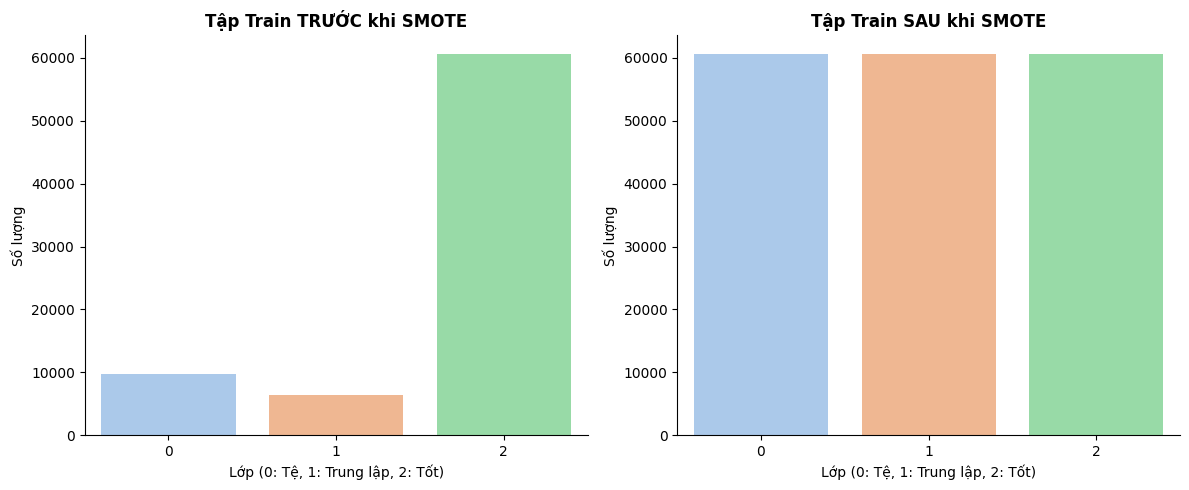

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# ==========================================
# 1. ĐỌC DỮ LIỆU VÀ CHUẨN BỊ NHÃN
# ==========================================
df = pd.read_csv('olist_final_dataset_labeled.csv')

def label_3_class(score):
    if score <= 2: return 0  # Không hài lòng
    if score == 3: return 1  # Trung lập
    return 2                 # Hài lòng

df['target'] = df['review_score'].apply(label_3_class)

features = ['norm_delivery_delay', 'norm_lead_time', 'norm_seller_speed', 
            'norm_freight_ratio', 'norm_installments', 'norm_desc_length', 
            'norm_photos_qty', 'norm_price']

X = df[features]
y = df['target']

# ==========================================
# 2. CHIA TẬP TRAIN/TEST (QUAN TRỌNG: Làm TRƯỚC khi SMOTE)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- 1. KÍCH THƯỚC DỮ LIỆU BAN ĐẦU ---")
print(f"Tập Train: {X_train.shape[0]} dòng")
print(f"Tập Test: {X_test.shape[0]} dòng (Sẽ được giữ nguyên)\n")

print("--- 2. PHÂN PHỐI NHÃN TẬP TRAIN (TRƯỚC KHI SMOTE) ---")
counter_before = Counter(y_train)
for k, v in counter_before.items():
    print(f"Lớp {k}: {v} mẫu ({v/len(y_train)*100:.2f}%)")

# ==========================================
# 3. ÁP DỤNG SMOTE LÊN TẬP TRAIN
# ==========================================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n--- 3. PHÂN PHỐI NHÃN TẬP TRAIN (SAU KHI SMOTE) ---")
counter_after = Counter(y_train_smote)
for k, v in counter_after.items():
    print(f"Lớp {k}: {v} mẫu ({v/len(y_train_smote)*100:.2f}%)")

# ==========================================
# 4. VẼ BIỂU ĐỒ SO SÁNH (Dùng cho Khóa luận)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ trước SMOTE
sns.countplot(x=y_train, ax=axes[0], palette='pastel')
axes[0].set_title('Tập Train TRƯỚC khi SMOTE', fontweight='bold')
axes[0].set_xlabel('Lớp (0: Tệ, 1: Trung lập, 2: Tốt)')
axes[0].set_ylabel('Số lượng')

# Biểu đồ sau SMOTE
sns.countplot(x=y_train_smote, ax=axes[1], palette='pastel')
axes[1].set_title('Tập Train SAU khi SMOTE', fontweight='bold')
axes[1].set_xlabel('Lớp (0: Tệ, 1: Trung lập, 2: Tốt)')
axes[1].set_ylabel('Số lượng')

sns.despine()
plt.tight_layout()
plt.show()
